# Exercise 06: Scatter Matrix

In [1]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix


conn = sqlite3.connect('../data/checking-logs.sqlite')



## Creating dataframes

In [2]:
# pageviews
views = pd.read_sql("""
SELECT uid, COUNT(*) as pageviews
FROM pageviews
WHERE uid LIKE 'user_%'
GROUP BY uid
""", conn)

# commits (exclude project1)
commits = pd.read_sql("""
SELECT uid, COUNT(*) as num_commits
FROM checker
WHERE uid LIKE 'user_%' AND labname != 'project1'
GROUP BY uid
""", conn)

# avg diff
diff = pd.read_sql("""
SELECT uid, AVG(diff) as avg_diff
FROM (
    SELECT c.uid,
    (strftime('%s', MIN(c.timestamp)) - d.deadlines)/3600.0 as diff
    FROM checker c
    JOIN deadlines d
    ON c.labname = d.labs
    WHERE c.uid LIKE 'user_%' AND c.labname != 'project1'
    GROUP BY c.uid, c.labname
)
GROUP BY uid
""", conn)

df = views.merge(commits, on='uid').merge(diff, on='uid')

conn.close()


## Plotting Scatter Matrix

array([[<Axes: xlabel='avg_diff', ylabel='avg_diff'>,
        <Axes: xlabel='pageviews', ylabel='avg_diff'>,
        <Axes: xlabel='num_commits', ylabel='avg_diff'>],
       [<Axes: xlabel='avg_diff', ylabel='pageviews'>,
        <Axes: xlabel='pageviews', ylabel='pageviews'>,
        <Axes: xlabel='num_commits', ylabel='pageviews'>],
       [<Axes: xlabel='avg_diff', ylabel='num_commits'>,
        <Axes: xlabel='pageviews', ylabel='num_commits'>,
        <Axes: xlabel='num_commits', ylabel='num_commits'>]], dtype=object)

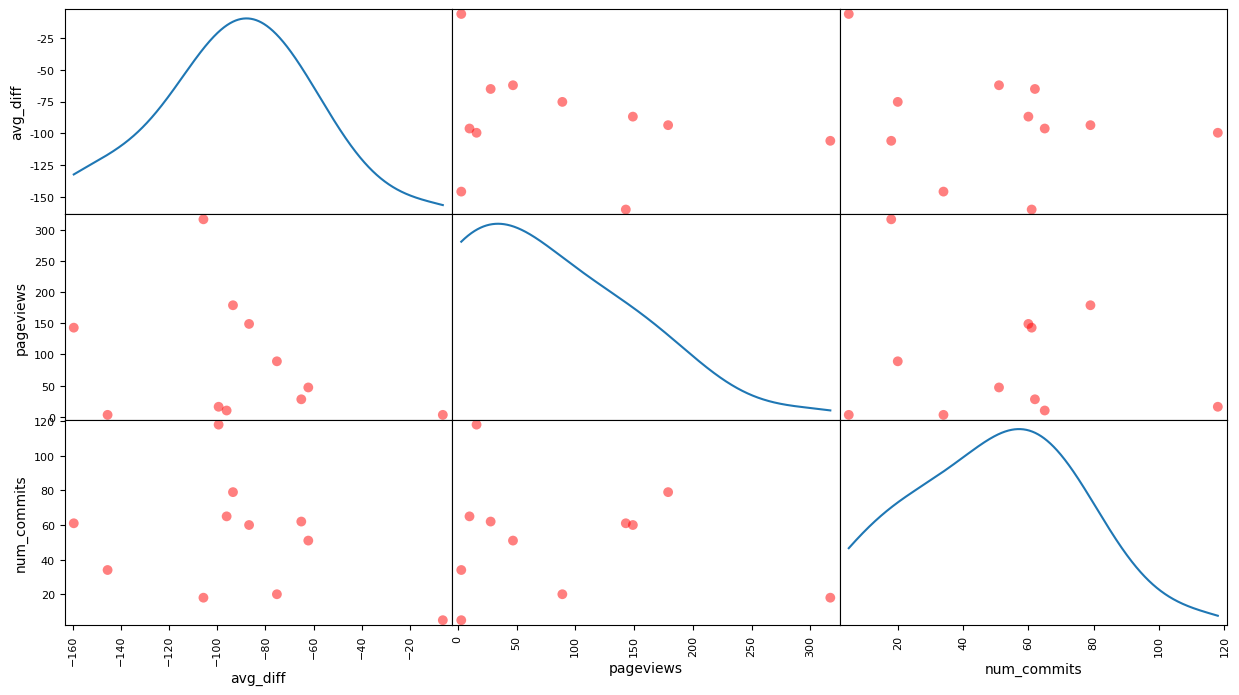

In [3]:
scatter_matrix(
    df[['avg_diff', 'pageviews', 'num_commits']],
    figsize=(15, 8),
    diagonal='kde',  # safe (no scipy)
    color='red',
    s=200
)

# NEED TO INSTALL SciPy to use KDE 

Can we say that if a user has a low number of pageviews, then they likely have a low number of commits? 
NO

Can we say that if a user has a low number of pageviews, then they likely have a small average difference between the first commit and the lab deadline?
NO 

Can we say that there are many users with a low number of commits and a few with a high number of commits? 
YES

Can we say that there are many users with a small average difference and a few with a large average difference?
YES